In [2]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.1 MB 8.0 MB/s eta 0:00:01
   -------------- ------------------------- 2.9/8.1 MB 7.6 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.1 MB 8.4 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.1 MB 9.0 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 8.0 MB/s  0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ------------------------------- -------- 1.8/2.3 MB 8.4 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 8.2 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ----------- ---------------------------- 2.1/7.0 MB 10.7 MB/s eta 0:00:01
   ---------------------- ----------------- 3.9/7.0 MB 10.6 MB/s eta 0:00

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd

from transformers import GPT2LMHeadModel, GPT2Tokenizer
from einops import rearrange

torch.manual_seed(0)

In [4]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

baseline_model = GPT2LMHeadModel.from_pretrained("gpt2")
baseline_model.eval()


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [5]:
text = "Artificial intelligence is"
inputs = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    baseline_logits = baseline_model(**inputs).logits


In [6]:
def kronecker_decompose(W, m, n, k=1):
    out_dim, in_dim = W.shape
    m2 = out_dim // m
    n2 = in_dim // n

    W_re = rearrange(
        W,
        '(m m2) (n n2) -> (m n) (m2 n2)',
        m=m, m2=m2, n=n, n2=n2
    )

    U, S, V = torch.svd_lowrank(W_re, q=k)

    A = rearrange(U, '(m n) k -> k m n', m=m, n=n)
    B = rearrange(V, '(m2 n2) k -> k m2 n2', m2=m2, n2=n2)

    scale = S.sqrt().view(-1, 1, 1)

    return A * scale, B * scale


In [7]:
def adaptive_normalize(W, A, B):
    W_hat = torch.kron(A[0], B[0])
    alpha = torch.norm(W, p="fro") / torch.norm(W_hat, p="fro")
    return A * torch.sqrt(alpha), B * torch.sqrt(alpha)


In [8]:
class KroneckerLinear(nn.Module):
    def __init__(self, A, B, bias):
        super().__init__()
        self.A = nn.Parameter(A)
        self.B = nn.Parameter(B)
        self.bias = nn.Parameter(bias.clone())

    def forward(self, x):
        y = torch.matmul(x, self.A)
        y = y.unsqueeze(-1) * self.B
        y = y.reshape(y.shape[0], y.shape[1], -1)
        return y + self.bias


In [9]:
class KroneckerLinearProj(nn.Module):
    def __init__(self, A, B, bias):
        super().__init__()
        self.A = nn.Parameter(A)
        self.B = nn.Parameter(B)
        self.bias = nn.Parameter(bias.clone())

    def forward(self, x):
        x = x.view(x.shape[0], x.shape[1], -1, 2)
        x = (x * self.B).sum(dim=-1)
        x = torch.matmul(x, self.A.t())
        return x + self.bias


In [10]:
def compress_one_layer(model, layer_idx):
    block = model.transformer.h[layer_idx]

    # ---- c_fc ----
    W_fc = block.mlp.c_fc.weight
    b_fc = block.mlp.c_fc.bias

    A_fc, B_fc = kronecker_decompose(W_fc, m=768, n=1536)
    A_fc, B_fc = adaptive_normalize(W_fc, A_fc, B_fc)

    block.mlp.c_fc = KroneckerLinear(
        A_fc[0],
        B_fc[0],
        b_fc
    )

    # ---- c_proj ----
    W_proj = block.mlp.c_proj.weight.T
    b_proj = block.mlp.c_proj.bias

    A_p, B_p = kronecker_decompose(W_proj, m=768, n=1536)
    A_p, B_p = adaptive_normalize(W_proj, A_p, B_p)

    block.mlp.c_proj = KroneckerLinearProj(
        A_p[0],
        B_p[0],
        b_proj
    )


In [11]:
results = []

for k in range(13):  # 0 to 12 layers
    model_k = GPT2LMHeadModel.from_pretrained("gpt2")
    model_k.eval()

    for layer_idx in range(k):
        compress_one_layer(model_k, layer_idx)

    with torch.no_grad():
        logits_k = model_k(**inputs).logits

    rel_diff = torch.norm(baseline_logits - logits_k) / torch.norm(baseline_logits)

    results.append((k, rel_diff.item()))
    print(f"Compressed layers: {k}, Relative logit diff: {rel_diff.item():.4f}")


Compressed layers: 0, Relative logit diff: 0.0000
Compressed layers: 1, Relative logit diff: 0.1281
Compressed layers: 2, Relative logit diff: 0.2005
Compressed layers: 3, Relative logit diff: 0.8030
Compressed layers: 4, Relative logit diff: 0.6204
Compressed layers: 5, Relative logit diff: 0.5021
Compressed layers: 6, Relative logit diff: 1.0938
Compressed layers: 7, Relative logit diff: 0.8297
Compressed layers: 8, Relative logit diff: 0.8014
Compressed layers: 9, Relative logit diff: 0.7612
Compressed layers: 10, Relative logit diff: 0.6828
Compressed layers: 11, Relative logit diff: 0.4642
Compressed layers: 12, Relative logit diff: 0.7059


In [12]:
df = pd.DataFrame(results, columns=["Compressed Layers", "Relative Logit Difference"])
df


,Compressed Layers,Relative Logit Difference
0,0,0.000000
1,1,0.128103
2,2,0.200529
3,3,0.803001
4,4,0.620372
5,5,0.502147
6,6,1.093843
7,7,0.829715
8,8,0.801439
9,9,0.761180


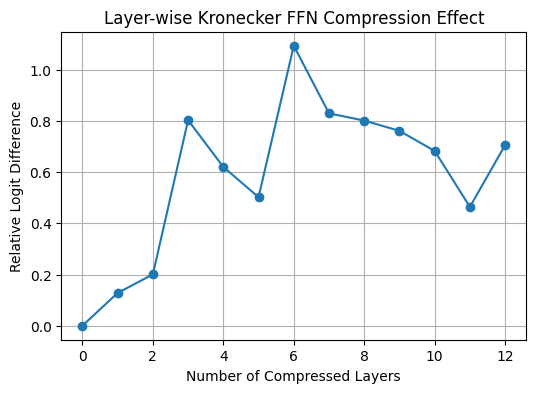

In [13]:
plt.figure(figsize=(6,4))
plt.plot(df["Compressed Layers"], df["Relative Logit Difference"], marker="o")
plt.xlabel("Number of Compressed Layers")
plt.ylabel("Relative Logit Difference")
plt.title("Layer-wise Kronecker FFN Compression Effect")
plt.grid(True)
plt.show()

In [14]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

original_model = GPT2LMHeadModel.from_pretrained("gpt2")
original_model.eval()

total_original_params = count_parameters(original_model)

print(f"Total GPT-2 parameters: {total_original_params:,}")

Total GPT-2 parameters: 124,439,808


In [15]:
def count_ffn_parameters(model):
    total = 0
    for block in model.transformer.h:
        total += block.mlp.c_fc.weight.numel()
        total += block.mlp.c_fc.bias.numel()
        total += block.mlp.c_proj.weight.numel()
        total += block.mlp.c_proj.bias.numel()
    return total

original_ffn_params = count_ffn_parameters(original_model)

print(f"Original FFN parameters: {original_ffn_params:,}")

Original FFN parameters: 56,669,184


In [16]:
def compressed_ffn_parameters():
    # c_fc
    A_fc = 768 * 1536
    B_fc = 1 * 2
    bias_fc = 3072

    # c_proj
    A_proj = 768 * 1536
    B_proj = 1 * 2
    bias_proj = 768

    per_layer = (
        A_fc + B_fc + bias_fc +
        A_proj + B_proj + bias_proj
    )

    total = per_layer * 12
    return total

compressed_ffn_params = compressed_ffn_parameters()

print(f"Compressed FFN parameters: {compressed_ffn_params:,}")


Compressed FFN parameters: 28,357,680


In [17]:
non_ffn_params = total_original_params - original_ffn_params

total_compressed_params = non_ffn_params + compressed_ffn_params

print(f"Total compressed model parameters: {total_compressed_params:,}")


Total compressed model parameters: 96,128,304


In [18]:
reduction = (total_original_params - total_compressed_params) / total_original_params * 100

print(f"Parameter reduction: {reduction:.2f}%")


Parameter reduction: 22.75%
